In [5]:
import zipfile
import os

zip_path = 'ius.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('new_human_dataset')

print("Распаковано в папку 'new_human_dataset'")

Распаковано в папку 'new_human_dataset'


In [6]:
import os
import glob

data_folder = 'new_human_dataset/ius_texts'

txt_files = glob.glob(os.path.join(data_folder, '*.txt'))
print(f"Всего txt файлов: {len(txt_files)}")

Всего txt файлов: 407


In [8]:
new_human_texts = []
short_texts = 0
empty_texts = 0
file_names = []

for file_path in txt_files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read().strip()
            
            if len(text) == 0:
                empty_texts += 1
            elif len(text) < 100:
                short_texts += 1
            else:
                new_human_texts.append(text)
                file_names.append(os.path.basename(file_path))
    except Exception as e:
        print(f"Ошибка при чтении {file_path}: {e}")

print(f"\nРезультаты фильтрации:")
print(f"  - Загружено текстов: {len(new_human_texts)}")
print(f"  - Отброшено коротких (<100 символов): {short_texts}")


Результаты фильтрации:
  - Загружено текстов: 407
  - Отброшено коротких (<100 символов): 0


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('train-kenlm.csv')
print(df.shape)
print(df.columns)
print(df['label'].value_counts())

(35158, 2)
Index(['text', 'label'], dtype='object')
label
gpt-4-turbo      8801
llama-3.3-70b    8798
gemma-2-27b      8790
human            8769
Name: count, dtype: int64


In [10]:
text_column = 'text'
label_column = 'label'

df_human = df[df[label_column] == 'human']
df_machine = df[df[label_column] != 'human']

print(f"Human: {len(df_human)}")
print(f"Machine: {len(df_machine)}")

Human: 8769
Machine: 26389


In [11]:
train_texts = df_human[text_column].tolist()
print(f"Всего human для обучения: {len(train_texts)}")

Всего human для обучения: 8769


In [12]:
df_llama_train = df[df[label_column].str.contains('llama-3.3-70b', case=False, na=False)]
llama_train_texts = df_llama_train[text_column].tolist()

print(f"Текстов от llama-3.3-70b для обучения: {len(llama_train_texts)}")

train_texts_all = train_texts + llama_train_texts
print(f"Всего текстов для обучения KenLM: {len(train_texts_all)}")
print(f"  - Human: {len(train_texts)}")
print(f"  - Llama: {len(llama_train_texts)}")

Текстов от llama-3.3-70b для обучения: 8798
Всего текстов для обучения KenLM: 17567
  - Human: 8769
  - Llama: 8798


In [13]:
with open('train_texts.txt', 'w', encoding='utf-8') as f:
    for text in train_texts_all:
        if isinstance(text, str) and len(text.strip()) > 0:
            f.write(text.strip() + '\n')

print("train_texts.txt сохранен")
!wc -l train_texts.txt

train_texts.txt сохранен
17566 train_texts.txt


In [14]:
import os
import subprocess

bin_path = os.path.abspath("kenlm-master/build/bin")
lmplz_path = os.path.join(bin_path, "lmplz")
build_binary_path = os.path.join(bin_path, "build_binary")

print("Обучение KenLM модели...")

!{lmplz_path} -o 3 < train_texts.txt > model.arpa
!{build_binary_path} model.arpa model.binary

!ls -lh model.arpa model.binary

import kenlm
model = kenlm.Model('model.binary')
print("Модель успешно загружена!")

Обучение KenLM модели...
=== 1/5 Counting and sorting n-grams ===
Reading /workspace/cloud/experiments/train_texts.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 1721611 types 176988
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:2123856 2:1141833088 3:2140936960
Statistics:
1 176988 D1=0.6805 D2=1.06138 D3+=1.44008
2 925406 D1=0.831721 D2=1.18424 D3+=1.41394
3 1409221 D1=0.900263 D2=1.31158 D3+=1.4776
Memory estimate for binary LM:
type    MB
probing 49 assuming -p 1.5
probing 55 assuming -r models -p 1.5
trie    23 without quantization
trie    14 assuming -q 8 -b 8 quantization 
trie    22 assuming -a 22 array pointer compression
trie    13 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:2123856 2:1480

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df_dev = pd.read_csv('dev_full.csv', 
                     encoding='utf-8', 
                     engine='python', 
                     on_bad_lines='skip')

print(f"Размер dev_full.csv: {df_dev.shape}")
print(f"Колонки: {df_dev.columns.tolist()}")
print(f"\nРаспределение label:\n{df_dev['label'].value_counts()}")

Размер dev_full.csv: (10978, 2)
Колонки: ['text', 'label']

Распределение label:
label
gpt-4-turbo      2205
gemma-2-27b      2204
llama-3.3-70b    2203
abstract         2193
unknown          2173
Name: count, dtype: int64


In [19]:
dev_llama = df_dev[df_dev['label'].str.contains('llama-3.3-70b', case=False, na=False)]
llama_texts = dev_llama['text'].tolist()
print(f"Текстов от llama-3.3-70b в dev: {len(llama_texts)}")

dev_human = df_dev[df_dev['label'] == 'abstract']
human_texts = dev_human['text'].tolist()
print(f"Человеческих текстов в dev: {len(human_texts)}")

Текстов от llama-3.3-70b в dev: 2203
Человеческих текстов в dev: 2193


In [41]:
from sklearn.model_selection import train_test_split

human_val, human_test = train_test_split(
    human_texts, 
    test_size=0.5, 
    random_state=42,
    shuffle=True
)

llama_val, llama_test = train_test_split(
    llama_texts, 
    test_size=0.5, 
    random_state=42,
    shuffle=True
)

print(f"\nВалидация:")
print(f"  Human: {len(human_val)}")
print(f"  Llama: {len(llama_val)}")


Валидация:
  Human: 1096
  Llama: 1101


In [40]:
# Валидационные файлы
with open('val_human.txt', 'w', encoding='utf-8') as f:
    for text in human_val:
        f.write(text.strip() + '\n')

with open('val_llama.txt', 'w', encoding='utf-8') as f:
    for text in llama_val:
        f.write(text.strip() + '\n')

print("Файлы сохранены")

Файлы сохранены


In [22]:
def get_perplexity(model, text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return None
    try:
        log_prob = model.score(text)
        words = text.split()
        return 2.0 ** (-log_prob / len(words)) if words else None
    except:
        return None

In [23]:
with open('val_human.txt', 'r', encoding='utf-8') as f:
    val_human = [line.strip() for line in f.readlines() if line.strip()]

with open('val_llama.txt', 'r', encoding='utf-8') as f:
    val_llama = [line.strip() for line in f.readlines() if line.strip()]

print(f"Валидация: human={len(val_human)}, llama={len(val_llama)}")

val_human_ppl = [get_perplexity(model, text) for text in val_human]
val_human_ppl = [x for x in val_human_ppl if x is not None]

val_llama_ppl = [get_perplexity(model, text) for text in val_llama]
val_llama_ppl = [x for x in val_llama_ppl if x is not None]

print(f"  Среднее ppl human: {np.mean(val_human_ppl):.2f}")
print(f"  Среднее ppl llama: {np.mean(val_llama_ppl):.2f}")

Валидация: human=1096, llama=1101
  Среднее ppl human: 10.97
  Среднее ppl llama: 5.98



Средняя перплексия:
  Обучающая выборка (human): 10.97
  Новые human тексты:        12.11
  Разница:                   1.13


/tmp/ipykernel_13378/1945668659.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([val_human_ppl, new_human_ppl], labels=['Обучающая выборка', 'Новые тексты'])


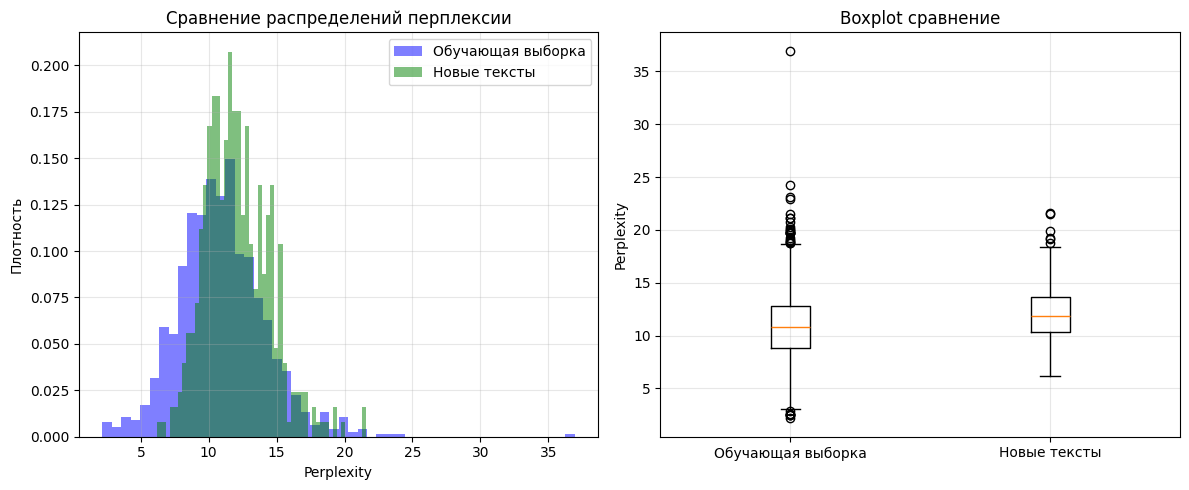

In [25]:
import numpy as np
import matplotlib.pyplot as plt

print(f"\nСредняя перплексия:")
print(f"  Обучающая выборка (human): {np.mean(val_human_ppl):.2f}")
print(f"  Новые human тексты:        {np.mean(new_human_ppl):.2f}")
print(f"  Разница:                   {np.mean(new_human_ppl) - np.mean(val_human_ppl):.2f}")

# Визуализация распределений
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(val_human_ppl, bins=50, alpha=0.5, label='Обучающая выборка', density=True, color='blue')
plt.hist(new_human_ppl, bins=50, alpha=0.5, label='Новые тексты', density=True, color='green')
plt.xlabel('Perplexity')
plt.ylabel('Плотность')
plt.title('Сравнение распределений перплексии')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([val_human_ppl, new_human_ppl], labels=['Обучающая выборка', 'Новые тексты'])
plt.ylabel('Perplexity')
plt.title('Boxplot сравнение')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Обучающая выборка:
  Всего слов в текстах: 133848
  Уникальных слов: 13790
  Топ-10 частотных слов: [('и', 4953), ('в', 4092), ('с', 1892), ('на', 1892), ('В', 1091), ('для', 956), ('что', 845), ('при', 718), ('к', 673), ('по', 633)]

Новые тексты:
  Всего слов в текстах: 80710
  Уникальных слов: 7742
  Топ-10 частотных слов: [('и', 2527), ('в', 2011), ('на', 1184), ('с', 1164), ('для', 982), ('при', 670), ('к', 453), ('по', 427), ('системы', 401), ('Результаты:', 397)]

Пересечение словарей:
  Слов в обучающей выборке: 13790
  Слов в новых текстах: 7742
  Общих слов: 4167
  Только в обучающей: 9623
  Только в новых: 3575
  Jaccard similarity: 0.2400


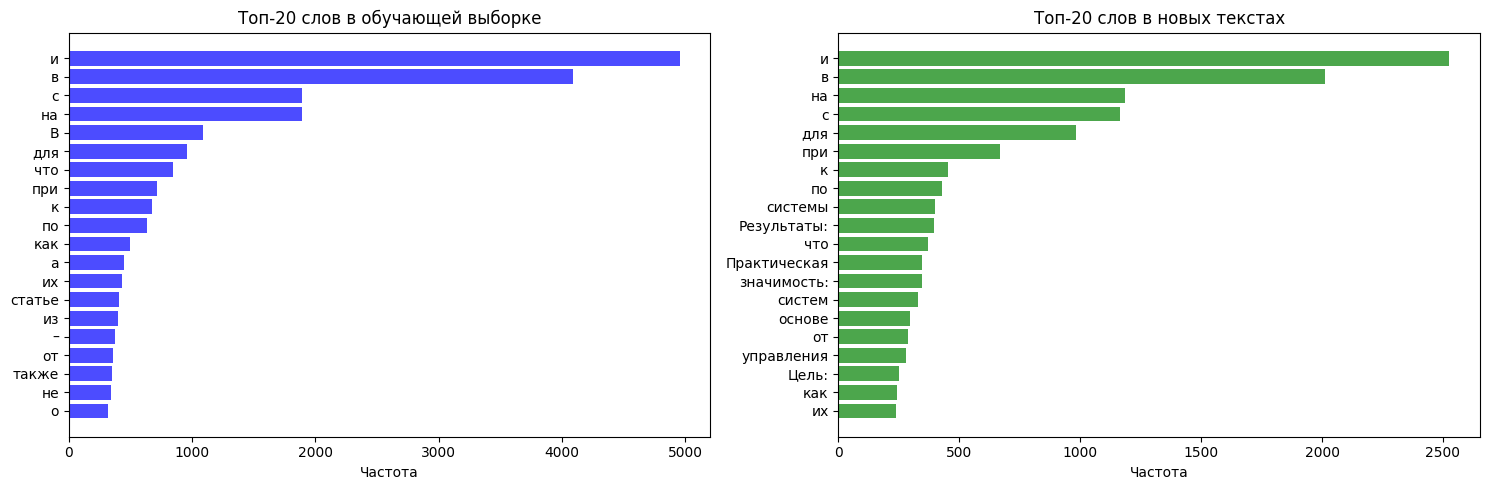


Редкие слова (частота < 3):
  В обучающей: 5554 слов (40.3%)
  В новых: 2743 слов (35.4%)

Примеры слов, которых нет в обучающей выборке:
  корректирующей
  нейронов.
  испытаний.
  требованием,
  вероятностных
  марковского
  подстроки
  отраженных
  подверглась
  видеопоследовательностях
  совпадающие
  решений:
  Граница
  критских
  сам
  произвольного
  метаданных
  прохождении
  осуществлено
  образующие.


In [30]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

def get_vocabulary(texts, min_freq=1):
    word_counter = Counter()
    total_words = 0
    
    for text in texts:
        words = text.split()
        total_words += len(words)
        word_counter.update(words)
    
    if min_freq > 1:
        word_counter = Counter({w: c for w, c in word_counter.items() if c >= min_freq})
    
    return word_counter, total_words

vocab_train, total_train_words = get_vocabulary(val_human, min_freq=2)
vocab_new, total_new_words = get_vocabulary(new_human_texts, min_freq=2)


print(f"\nОбучающая выборка:")
print(f"  Всего слов в текстах: {total_train_words}")
print(f"  Уникальных слов: {len(vocab_train)}")
print(f"  Топ-10 частотных слов: {list(vocab_train.most_common(10))}")

print(f"\nНовые тексты:")
print(f"  Всего слов в текстах: {total_new_words}")
print(f"  Уникальных слов: {len(vocab_new)}")
print(f"  Топ-10 частотных слов: {list(vocab_new.most_common(10))}")

train_words = set(vocab_train.keys())
new_words = set(vocab_new.keys())

common_words = train_words.intersection(new_words)
only_train = train_words - new_words
only_new = new_words - train_words

print(f"\nПересечение словарей:")
print(f"  Слов в обучающей выборке: {len(train_words)}")
print(f"  Слов в новых текстах: {len(new_words)}")
print(f"  Общих слов: {len(common_words)}")
print(f"  Только в обучающей: {len(only_train)}")
print(f"  Только в новых: {len(only_new)}")
print(f"  Jaccard similarity: {len(common_words) / len(train_words.union(new_words)):.4f}")

# Топ-20 слов в каждом словаре для визуализации
top_n = 20
top_train = vocab_train.most_common(top_n)
top_new = vocab_new.most_common(top_n)

top_train_words, top_train_counts = zip(*top_train)
top_new_words, top_new_counts = zip(*top_new)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.barh(range(top_n), top_train_counts, color='blue', alpha=0.7)
plt.yticks(range(top_n), top_train_words)
plt.xlabel('Частота')
plt.title(f'Топ-{top_n} слов в обучающей выборке')
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
plt.barh(range(top_n), top_new_counts, color='green', alpha=0.7)
plt.yticks(range(top_n), top_new_words)
plt.xlabel('Частота')
plt.title(f'Топ-{top_n} слов в новых текстах')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Анализ редких слов (потенциальный шум)
rare_in_train = [w for w, c in vocab_train.items() if c < 3]
rare_in_new = [w for w, c in vocab_new.items() if c < 3]

print(f"\nРедкие слова (частота < 3):")
print(f"  В обучающей: {len(rare_in_train)} слов ({len(rare_in_train)/len(vocab_train)*100:.1f}%)")
print(f"  В новых: {len(rare_in_new)} слов ({len(rare_in_new)/len(vocab_new)*100:.1f}%)")

if only_new:
    print(f"\nПримеры слов, которых нет в обучающей выборке:")
    for word in list(only_new)[:20]:
        print(f"  {word}")

In [31]:
import numpy as np
from collections import Counter

def text_vocab_similarity(text, train_vocab, threshold=0.5):
    words = set(text.split())
    if len(words) == 0:
        return 0
    common = words.intersection(train_vocab)
    return len(common) / len(words)

train_words_set = set(vocab_train.keys())

# Оцениваем каждый новый текст
similarities = []
outliers = []

for i, text in enumerate(new_human_texts):
    sim = text_vocab_similarity(text, train_words_set)
    similarities.append(sim)
    if sim < 0.5:
        outliers.append((i, sim, text[:200]))

print(f"Текстов с низким перекрытием словаря (<50%): {len(outliers)}")

# Удаляем выбросы
clean_texts = []
clean_ppl = []
for i, (text, ppl) in enumerate(zip(new_human_texts, new_human_ppl)):
    if similarities[i] >= 0.5:
        clean_texts.append(text)
        clean_ppl.append(ppl)

print(f"После фильтрации: {len(clean_texts)} текстов")

Текстов с низким перекрытием словаря (<50%): 4
После фильтрации: 403 текстов


In [35]:
import re

def normalize_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text) 
    return text.strip()

normalized_new = [normalize_text(t) for t in new_human_texts]
normalized_train = [normalize_text(t) for t in val_human]

In [37]:
final_texts = []
final_ppl = []

min_words = 50
max_words = 1000
max_ppl_percentile = 95

ppl_threshold = np.percentile(new_human_ppl, max_ppl_percentile)

for text, ppl in zip(new_human_texts, new_human_ppl):
    words = text.split()
    word_count = len(words)
    
    if (word_count >= min_words and 
        word_count <= max_words and 
        ppl <= ppl_threshold):
        final_texts.append(text)
        final_ppl.append(ppl)

print(f"После полной фильтрации: {len(final_texts)} текстов")

После полной фильтрации: 386 текстов


In [38]:
with open('new_human_clean.txt', 'w', encoding='utf-8') as f:
    for text in final_texts:
        f.write(text.strip() + '\n')

print(f"Сохранено {len(final_texts)} текстов в new_human_clean.txt")

print("\nСтатистика:")
print(f"  Было текстов: {len(new_human_texts)}")
print(f"  Стало: {len(final_texts)}")
print(f"  Средняя перплексия (было): {np.mean(new_human_ppl):.2f}")
print(f"  Средняя перплексия (стало): {np.mean(final_ppl):.2f}")

Сохранено 386 текстов в new_human_clean.txt

Статистика:
  Было текстов: 407
  Стало: 386
  Средняя перплексия (было): 12.11
  Средняя перплексия (стало): 11.79


Accuracy порог: 7.94 (acc=0.8776)
F1 порог:       7.94 (f1=0.8811)
AUC порог:   7.98 (auc=0.9299)


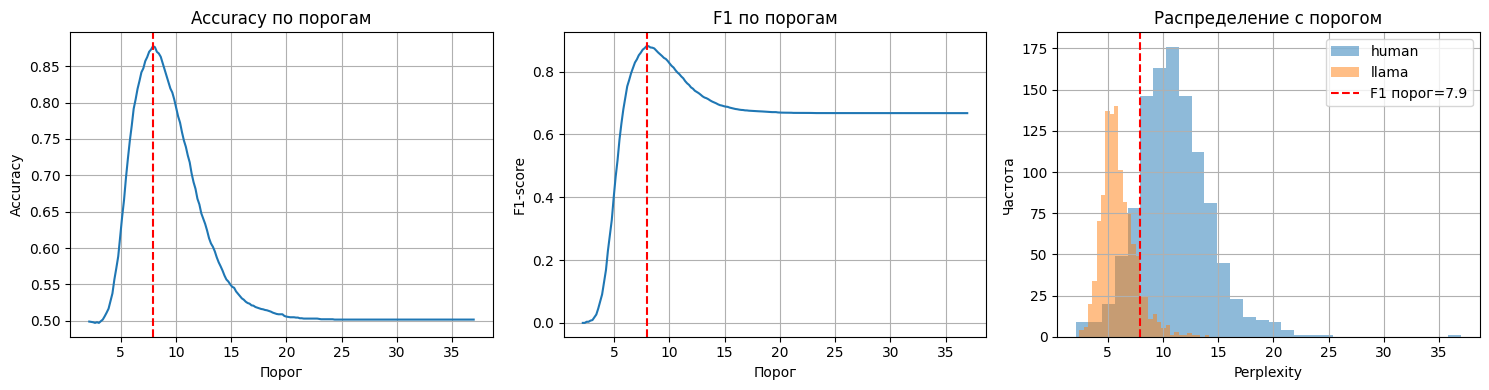

In [39]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

all_ppl = np.array(val_human_ppl + val_llama_ppl)
y_true = [0] * len(val_human_ppl) + [1] * len(val_llama_ppl)

thresholds = np.linspace(min(all_ppl), max(all_ppl), 200)

best_acc = 0
best_thresh_acc = None
acc_scores = []

for thresh in thresholds:
    y_pred = [1 if ppl < thresh else 0 for ppl in all_ppl]
    acc = accuracy_score(y_true, y_pred)
    acc_scores.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_thresh_acc = thresh

best_f1 = 0
best_thresh_f1 = None
f1_scores = []

for thresh in thresholds:
    y_pred = [1 if ppl < thresh else 0 for ppl in all_ppl]
    f1 = f1_score(y_true, y_pred)
    f1_scores.append(f1)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh_f1 = thresh

y_score = -all_ppl
val_auc = roc_auc_score(y_true, y_score)
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
youden = tpr - fpr
best_idx = np.argmax(youden)
best_thresh_youden = -roc_thresholds[best_idx]
best_youden = youden[best_idx]

print(f"Accuracy порог: {best_thresh_acc:.2f} (acc={best_acc:.4f})")
print(f"F1 порог:       {best_thresh_f1:.2f} (f1={best_f1:.4f})")
print(f"AUC порог:   {best_thresh_youden:.2f} (auc={val_auc:.4f})")

# Визуализация
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(thresholds, acc_scores)
plt.axvline(best_thresh_acc, color='red', linestyle='--')
plt.xlabel('Порог')
plt.ylabel('Accuracy')
plt.title('Accuracy по порогам')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(thresholds, f1_scores)
plt.axvline(best_thresh_f1, color='red', linestyle='--')
plt.xlabel('Порог')
plt.ylabel('F1-score')
plt.title('F1 по порогам')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.hist(val_human_ppl, bins=30, alpha=0.5, label='human')
plt.hist(val_llama_ppl, bins=30, alpha=0.5, label='llama')
plt.axvline(best_thresh_f1, color='red', linestyle='--', label=f'F1 порог={best_thresh_f1:.1f}')
plt.xlabel('Perplexity')
plt.ylabel('Частота')
plt.title('Распределение с порогом')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [64]:
import re
import os
import random

if os.path.exists('test_human_ood.txt'):
    os.remove('test_human_ood.txt')
    print("Старый test_human_ood.txt удален")

if os.path.exists('test_machine_ood.txt'):
    os.remove('test_machine_ood.txt')
    print("Старый test_machine_ood.txt удален")

n_samples = 564
print(f"\nЦелевое количество: {n_samples} текстов каждого класса")

clean_human_texts = final_texts[:n_samples]
print(f"Human текстов взято: {len(clean_human_texts)}")

selected_machine = random.sample(llama_test, n_samples)
print(f"Machine текстов взято: {len(selected_machine)}")

with open('test_human_ood.txt', 'w', encoding='utf-8') as f:
    for text in clean_human_texts:
        f.write(text.strip() + '\n')

with open('test_machine_ood.txt', 'w', encoding='utf-8') as f:
    for text in selected_machine:
        f.write(text.strip() + '\n')

print("\n✓ Файлы созданы заново:")
!wc -l test_human_ood.txt
!wc -l test_machine_ood.txt

def extract_text_from_line(line):
    """Извлекает текст из строки, убирая тему/название в начале"""
    line = line.strip()
    parts = re.split(r'\t|\.\s|:\s', line, maxsplit=1)
    if len(parts) > 1:
        return parts[1].strip()
    else:
        return line

# Читаем файл и извлекаем только текст
clean_human_texts = []
with open('test_human_ood.txt', 'r', encoding='utf-8') as f:
    for line in f:
        text = extract_text_from_line(line)
        if len(text) > 100:  # фильтруем короткие
            clean_human_texts.append(text)

print(f"Извлечено текстов: {len(clean_human_texts)}")

# Перезаписываем файл только с текстами
with open('test_human_ood_clean.txt', 'w', encoding='utf-8') as f:
    for text in clean_human_texts:
        f.write(text + '\n')

print(f"\nСохранено в test_human_ood_clean.txt")
!wc -l test_human_ood_clean.txt

Старый test_human_ood.txt удален
Старый test_machine_ood.txt удален

Целевое количество: 564 текстов каждого класса
Human текстов взято: 386
Machine текстов взято: 564

✓ Файлы созданы заново:
804 test_human_ood.txt
564 test_machine_ood.txt
Извлечено текстов: 564

Сохранено в test_human_ood_clean.txt
564 test_human_ood_clean.txt


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

with open('test_human_ood_clean.txt', 'r', encoding='utf-8') as f:
    test_human_ood = [line.strip() for line in f.readlines() if line.strip()]

with open('test_machine_ood.txt', 'r', encoding='utf-8') as f:
    test_machine_ood = [line.strip() for line in f.readlines() if line.strip()]

ood_human_ppl = []
for text in test_human_ood:
    ppl = get_perplexity(model, text)
    if ppl is not None:
        ood_human_ppl.append(ppl)

ood_machine_ppl = []
for text in test_machine_ood:
    ppl = get_perplexity(model, text)
    if ppl is not None:
        ood_machine_ppl.append(ppl)

test_all_ppl = np.array(ood_human_ppl + ood_machine_ppl)
y_test_true = [0] * len(ood_human_ppl) + [1] * len(ood_machine_ppl)

final_threshold = best_thresh_f1
y_test_pred = [1 if ppl < final_threshold else 0 for ppl in test_all_ppl]

print(f"Используем порог по F1: {final_threshold:.2f}")
print(f"Всего текстов: {len(test_all_ppl)}")
print(f"Предсказано machine: {sum(y_test_pred)} ({sum(y_test_pred)/len(test_all_ppl)*100:.1f}%)")
print(f"Предсказано human: {len(test_all_ppl) - sum(y_test_pred)} ({(len(test_all_ppl) - sum(y_test_pred))/len(test_all_ppl)*100:.1f}%)")

Используем порог по F1: 7.94
Всего текстов: 1128
Предсказано machine: 509 (45.1%)
Предсказано human: 619 (54.9%)


In [72]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

test_acc = accuracy_score(y_test_true, y_test_pred)
test_f1 = f1_score(y_test_true, y_test_pred)
test_auc = roc_auc_score(y_test_true, -test_all_ppl)

print(f"Accuracy:  {test_acc:.4f}")
print(f"F1-score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_auc:.4f}")

cm = confusion_matrix(y_test_true, y_test_pred)
print("\nМатрица ошибок:")
print("           Pred human  Pred machine")
print(f"Actual human    {cm[0,0]:5d}      {cm[0,1]:5d}")
print(f"Actual machine  {cm[1,0]:5d}      {cm[1,1]:5d}")

Accuracy:  0.9016
F1-score:  0.8966
ROC-AUC:   0.9722

Матрица ошибок:
           Pred human  Pred machine
Actual human      536         28
Actual machine     83        481


In [73]:
print(f"{'Метрика':<12} {'Валидация':>10} {'Тест':>10} {'Разница':>10}")
print("-"*50)
print(f"{'F1-score':<12} {best_f1:>10.4f} {test_f1:>10.4f} {test_f1 - best_f1:>+10.4f}")
print(f"{'Accuracy':<12} {best_acc:>10.4f} {test_acc:>10.4f} {test_acc - best_acc:>+10.4f}")
print(f"{'ROC-AUC':<12} {val_auc:>10.4f} {test_auc:>10.4f} {test_auc - val_auc:>+10.4f}")

Метрика       Валидация       Тест    Разница
--------------------------------------------------
F1-score         0.8811     0.8966    +0.0154
Accuracy         0.8776     0.9016    +0.0240
ROC-AUC          0.9299     0.9722    +0.0423


/tmp/ipykernel_13378/3538442317.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['human', 'llama'], patch_artist=True)


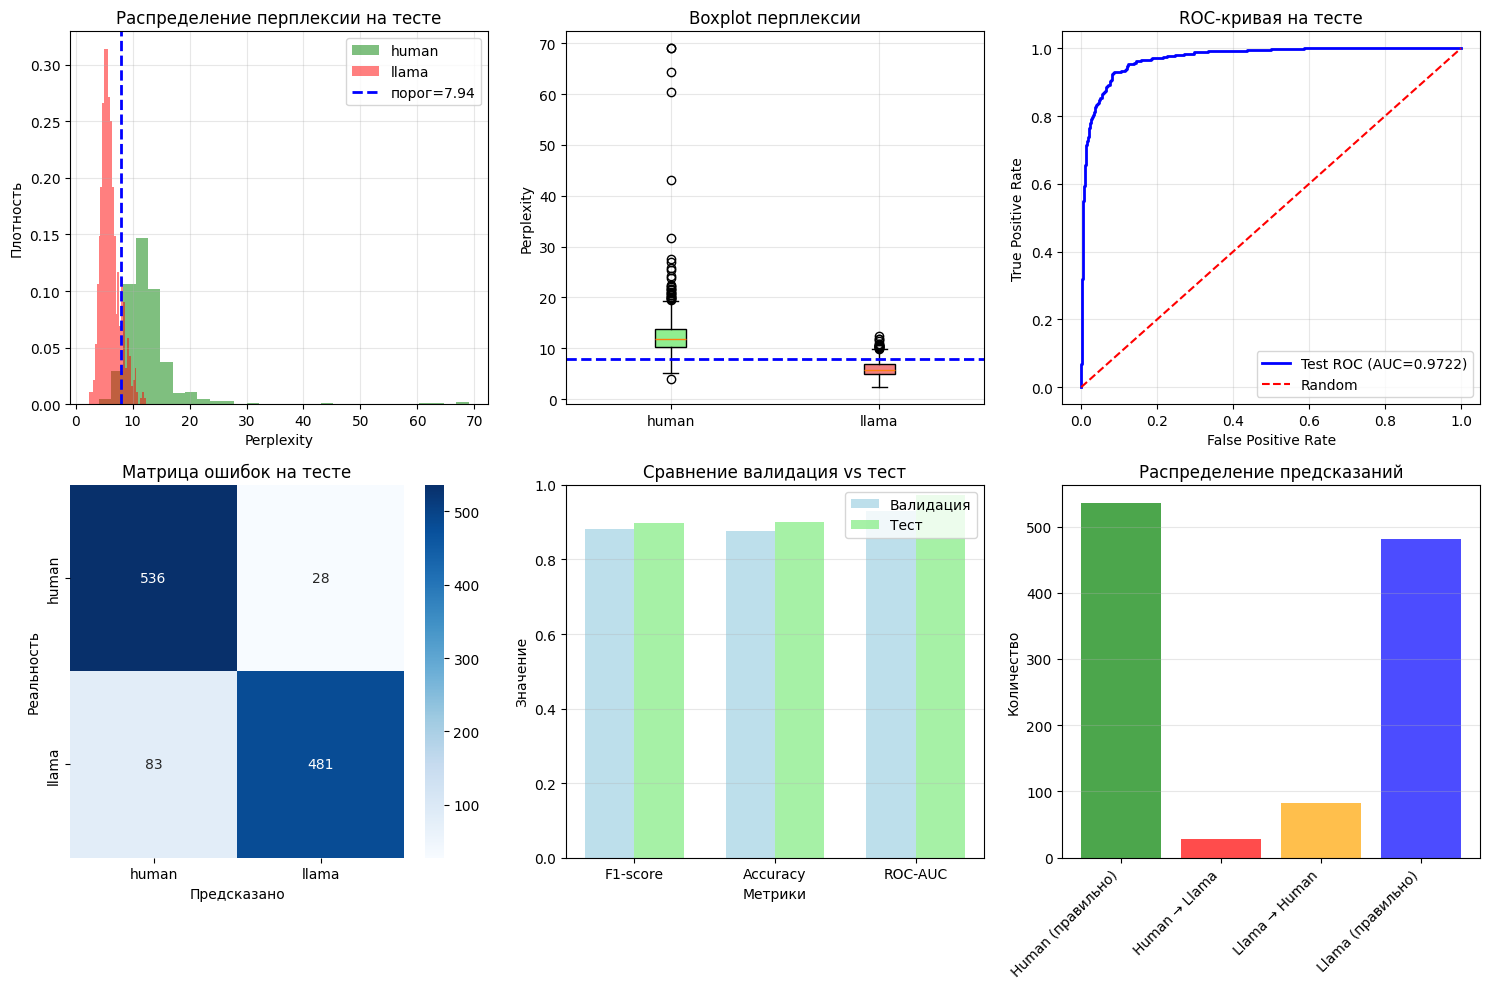


Итоговые метрики на тесте (порог F1=7.94):
  Accuracy: 0.9016
  F1-score: 0.8966
  ROC-AUC:  0.9722


In [76]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns

test_machine_ppl = ood_machine_ppl
test_human_ppl = ood_human_ppl
y_test_true = [0]*len(test_human_ppl) + [1]*len(test_machine_ppl)
y_test_score = -np.array(test_human_ppl + test_machine_ppl)

plt.figure(figsize=(15, 10))

# 1. Распределение перплексии на тесте
plt.subplot(2, 3, 1)
plt.hist(test_human_ppl, bins=30, alpha=0.5, label='human', density=True, color='green')
plt.hist(test_machine_ppl, bins=30, alpha=0.5, label='llama', density=True, color='red')
plt.axvline(x=final_threshold, color='blue', linestyle='--', linewidth=2, 
            label=f'порог={final_threshold:.2f}')
plt.xlabel('Perplexity')
plt.ylabel('Плотность')
plt.title('Распределение перплексии на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Boxplot
plt.subplot(2, 3, 2)
data_to_plot = [test_human_ppl, test_machine_ppl]
bp = plt.boxplot(data_to_plot, labels=['human', 'llama'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
plt.axhline(y=final_threshold, color='blue', linestyle='--', linewidth=2)
plt.ylabel('Perplexity')
plt.title('Boxplot перплексии')
plt.grid(True, alpha=0.3)

# 3. ROC-кривая
plt.subplot(2, 3, 3)
fpr_test, tpr_test, _ = roc_curve(y_test_true, y_test_score)
plt.plot(fpr_test, tpr_test, 'b-', linewidth=2, label=f'Test ROC (AUC={test_auc:.4f})')
plt.plot([0,1], [0,1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Матрица ошибок
plt.subplot(2, 3, 4)
cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['human', 'llama'], 
            yticklabels=['human', 'llama'])
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.title('Матрица ошибок на тесте')

# 5. Сравнение метрик валидация vs тест
plt.subplot(2, 3, 5)
metrics = ['F1-score', 'Accuracy', 'ROC-AUC']
val_values = [best_f1, best_acc, val_auc]
test_values = [test_f1, test_acc, test_auc]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, val_values, width, label='Валидация', color='lightblue', alpha=0.8)
plt.bar(x + width/2, test_values, width, label='Тест', color='lightgreen', alpha=0.8)
plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение валидация vs тест')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1])

# 6. Предсказания по классам
plt.subplot(2, 3, 6)
labels = ['Human (правильно)', 'Human → Llama', 'Llama → Human', 'Llama (правильно)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['green', 'red', 'orange', 'blue']
plt.bar(labels, values, color=colors, alpha=0.7)
plt.ylabel('Количество')
plt.title('Распределение предсказаний')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nИтоговые метрики на тесте (порог F1={final_threshold:.2f}):")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  F1-score: {test_f1:.4f}")
print(f"  ROC-AUC:  {test_auc:.4f}")